In [52]:
!pip install numpy 
# federated fuzzy means

import numpy as np

# Parameters
C = 2  # nb of centroid
m = 2.0
# m: mbship param, m=1 -> classical kmeans (:!\ not defined 
# m belongs [1.5;3]
# m small: clusters are tight and crisp
# m high:  clusters overlaps more
rounds = 20

# Simulated clients
client_data = [
    np.array([[1,1], [2,2], [3,3]], dtype=float),
    np.array([[8,8], [9,9], [10,10]], dtype=float)
]

# Initialize centroids
centroids = np.random.rand(C, 2)


class FuzzyKmeans:
    def __init__(self, k: int, mbship_param: float):
        self._n_centroid = k
        self._mbship_param = mbship_param
        self.weights = None
        self._centroids = np.random.rand(k, 2)
    
    def partial_fit(self, X):
        U = update_membership(X, self._centroids)

        c_local, w_local, xb_local = compute_local_stats(
            data, U, self._centroids
        )

        self._centroids = c_local
        self.weights = w_local
        xb_total += xb_local
        
        
    def predict(self, X):
        C = self._centroids.shape[0] 
        prediction = np.zeros(X.shape[0], C)
        
        for i in range(C):
            prediction[i,:] = np.linalg.norm(X - self._centroids[j])

        prediction = np.argmin(prediction)

        return prediction

    def score(self, X):
        pass

    def update_membership(self, data, centroids):
        N = data.shape[0] # nb data
        C = centroids.shape[0]  # nb centroids
        U = np.zeros((N, C))
    
        for i in range(N):
            for j in range(C):
                d_ij = np.linalg.norm(data[i] - centroids[j])
                if d_ij == 0:
                    U[i, :] = 0
                    U[i, j] = 1
                    continue
    
                sum_term = 0
                for k in range(C):
                    d_ik = np.linalg.norm(data[i] - centroids[k])
                    if d_ik == 0:
                        d_ik = 1e-6
                    sum_term += (d_ij / d_ik) ** (2 / (m - 1))
    
                U[i, j] = 1 / sum_term
        return U

    def compute_local_stats(self, data, U, centroids):
        um = U ** m
    
        # Local centroid
        c_local = (um.T @ data) / np.sum(um.T, axis=1, keepdims=True)
    
        # Weights for aggregation
        weights = np.sum(um, axis=0)
    
        # XB numerator contribution
        xb_local = 0
        for i in range(data.shape[0]):
            for j in range(self._n_centroid):
                dist_sq = np.linalg.norm(data[i] - centroids[j]) ** 2
                xb_local += um[i, j] * dist_sq
    
        return c_local, weights, xb_local
        
def update_membership(data, centroids):
    N = data.shape[0]
    C = centroids.shape[0]
    U = np.zeros((N, C))

    for i in range(N):
        for j in range(C):
            d_ij = np.linalg.norm(data[i] - centroids[j])
            if d_ij == 0:
                U[i, :] = 0
                U[i, j] = 1
                continue

            sum_term = 0
            for k in range(C):
                d_ik = np.linalg.norm(data[i] - centroids[k])
                if d_ik == 0:
                    d_ik = 1e-6
                sum_term += (d_ij / d_ik) ** (2 / (m - 1))

            U[i, j] = 1 / sum_term
    return U

def compute_local_stats(data, U, centroids):
    um = U ** m

    # Local centroid
    c_local = (um.T @ data) / np.sum(um.T, axis=1, keepdims=True)

    # Weights for aggregation
    weights = np.sum(um, axis=0)

    # XB numerator contribution
    xb_local = 0
    for i in range(data.shape[0]):
        for j in range(C):
            dist_sq = np.linalg.norm(data[i] - centroids[j]) ** 2
            xb_local += um[i, j] * dist_sq

    return c_local, weights, xb_local, data.shape[0]

def compute_xb(centroids, xb_numerator, total_points):
    # separation (min distance between centroids)
    min_dist = float('inf')
    for i in range(C):
        for j in range(i + 1, C):
            dist = np.linalg.norm(centroids[i] - centroids[j]) ** 2
            if dist < min_dist:
                min_dist = dist

    return xb_numerator / (total_points * min_dist)

# Federated loop
for r in range(rounds):
    local_centroids = []
    weights = []
    xb_total = 0
    total_points = 0

    for data in client_data:
        U = update_membership(data, centroids)

        c_local, w_local, xb_local, n_local = compute_local_stats(
            data, U, centroids
        )

        local_centroids.append(c_local)
        weights.append(w_local)
        xb_total += xb_local
        total_points += n_local

    # Aggregate centroids
    new_centroids = np.zeros_like(centroids)
    total_weights = np.sum(weights, axis=0)

    for j in range(C):
        for k in range(len(client_data)):
            new_centroids[j] += weights[k][j] * local_centroids[k][j]
        new_centroids[j] /= total_weights[j]

    centroids = new_centroids

    # Compute XB index
    xb = compute_xb(centroids, xb_total, total_points)
    print(f"Round {r+1}, XB Index: {xb:.4f}")

print("\nFinal Centroids:\n", centroids)

Round 1, XB Index: 2.4292
Round 2, XB Index: 0.1084
Round 3, XB Index: 0.0163
Round 4, XB Index: 0.0133
Round 5, XB Index: 0.0133
Round 6, XB Index: 0.0133
Round 7, XB Index: 0.0133
Round 8, XB Index: 0.0133
Round 9, XB Index: 0.0133
Round 10, XB Index: 0.0133
Round 11, XB Index: 0.0133
Round 12, XB Index: 0.0133
Round 13, XB Index: 0.0133
Round 14, XB Index: 0.0133
Round 15, XB Index: 0.0133
Round 16, XB Index: 0.0133
Round 17, XB Index: 0.0133
Round 18, XB Index: 0.0133
Round 19, XB Index: 0.0133
Round 20, XB Index: 0.0133

Final Centroids:
 [[9.00596038 9.00596038]
 [1.99403962 1.99403962]]


In [54]:
len(client_data)

2

In [1]:
import numpy as np
# dataset parameters
SEED = 1234
np.random.seed(SEED)

## parameters for data generation
cluster_centers = [[1, 1], [-1, -1], [1, -1], [0, 1]]
n_samples = 200
cluster_std = .5
space_dim = 2

nb_samples_per_nodes = [1, 1, 1, 1] # indicates how to sample data per node

In [2]:
from sklearn.datasets import make_blobs

X, labels_true = make_blobs(n_samples=n_samples,
                            centers=cluster_centers, cluster_std=cluster_std,
                           random_state=SEED)

In [3]:
labels_true

array([1, 1, 2, 3, 2, 3, 3, 3, 1, 0, 3, 0, 3, 1, 3, 0, 2, 2, 1, 2, 0, 2,
       2, 1, 2, 0, 1, 3, 2, 2, 2, 1, 3, 1, 1, 2, 1, 0, 1, 1, 3, 1, 0, 3,
       2, 2, 1, 2, 2, 3, 2, 3, 0, 1, 1, 3, 1, 0, 3, 3, 1, 0, 0, 0, 0, 2,
       3, 0, 3, 2, 3, 3, 3, 2, 0, 3, 0, 2, 3, 2, 2, 1, 0, 1, 0, 0, 3, 2,
       1, 2, 1, 2, 0, 0, 1, 3, 3, 2, 2, 2, 2, 1, 1, 3, 2, 3, 0, 0, 1, 0,
       1, 1, 0, 0, 3, 1, 2, 1, 3, 2, 2, 1, 2, 0, 1, 3, 2, 1, 1, 0, 3, 0,
       2, 0, 3, 0, 0, 0, 0, 1, 0, 0, 3, 2, 3, 2, 2, 3, 1, 3, 2, 2, 0, 1,
       1, 0, 3, 0, 1, 0, 0, 1, 2, 0, 3, 1, 2, 0, 0, 1, 2, 1, 3, 3, 3, 2,
       2, 2, 0, 3, 1, 0, 3, 3, 3, 1, 2, 1, 0, 3, 0, 1, 0, 1, 3, 0, 3, 3,
       2, 1])

In [ ]:
to get best k : use K=argminXB

In [92]:

class FuzzyKmeans:
    def __init__(self, k: int, mbship_param: float):

        assert mbship_param > 1, "cannot use fuzzykmeans for mbship_param = " + str(mbship_param)
        self._n_centroid = k
        self._mbship_param = mbship_param
        self._weights = []
        self._centroids = None
        self.U = None
    
    def partial_fit(self, X):
        if self._centroids is None:
            # initialize centroids
            idx = np.random.choice(X.shape[0], self._n_centroid, replace=False)
            self._centroids = X[idx]
        self._score = 0
        U = self.update_membership(X, self._centroids)
        self.U = U
        centroids, w, xb_score = self.compute_local_stats(X, U, self._centroids)
        self._centroids = centroids
        self._score = xb_score
        print("w",w)
        self._weights = w
        
    def predict(self, X):
        #C = self._centroids.shape[0] 
        #prediction = np.zeros((X.shape[0], C))
        U = self.update_membership(X, self._centroids)
        labels = np.argmax(U, axis=1)
        #for j in range(X.shape[0]):
        #    for i in range(C):
                
        #        prediction[j,i] = np.linalg.norm(X[j,:] - self._centroids[i])

        #prediction = np.argmin(prediction, axis=1)

        return labels

    def score(self, X):
        """returns Xie Beni estimator
        XB=\frac{\sum_i\sum_j u_{ij}^m\|x_i-c_j\|^2} {N\min_{p\neq q}\|c_p-c_q\|^2}
        """
        # separation (min distance between centroids)

        um = self.U ** self._mbship_param
        xb_local = 0
        total_points = X.shape[0]
        min_dist = float('inf')
        C = self._centroids.shape[0] 
        for i in range(X.shape[0]):
            for j in range(C):
                dist_sq = np.linalg.norm(X[i] - self._centroids[j]) ** 2
                xb_local += um[i, j] * dist_sq


        min_dist = np.inf

        for i in range(C):
            for j in range(i+1, C):
                d = np.linalg.norm(self._centroids[i] - self._centroids[j])**2
                min_dist = min(min_dist, d)
        
        xb = xb_local / (len(X) * min_dist)
        return xb

    def update_membership(self, data, centroids):
        N = data.shape[0] # nb data
        C = centroids.shape[0]  # nb centroids
        U = np.zeros((N, C))

        
        for i in range(N):
            assigned = False
            for j in range(C):
                d_ij = np.linalg.norm(data[i] - centroids[j])
                if d_ij == 0:
                    U[i, :] = 0
                    U[i, j] = 1
                    assigned = True
                    break
            if assigned:
                continue
            for j in range(C):
                d_ij = np.linalg.norm(data[i] - centroids[j])
                sum_term = 0
                for k in range(C):
                    d_ik = np.linalg.norm(data[i] - centroids[k])
                    if d_ik == 0:
                        d_ik = 1e-6
                    sum_term += (d_ij / d_ik) ** (2 / (self._mbship_param - 1))
    
                U[i, j] = 1 / sum_term
        return U

    def compute_local_stats(self, data, U, centroids):
        C = centroids.shape[0]  # nb centroids
        um = U ** self._mbship_param
    
        # Local centroid
        c_local = (um.T @ data) / np.sum(um.T, axis=1, keepdims=True)
    
        # Weights for aggregation
        weights = np.sum(um, axis=0)
        
        # XB numerator contribution
        xb_local = 0
        for i in range(data.shape[0]):
            for j in range(C):
                dist_sq = np.linalg.norm(data[i] - c_local[j]) ** 2
                xb_local += um[i, j] * dist_sq
    
        return c_local, weights,  xb_local

<>:40: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_882/1342981163.py:40: SyntaxWarning: invalid escape sequence '\s'
  """returns Xie Beni estimator


In [93]:
fuzzy_k_means = FuzzyKmeans(4, 2)
print(fuzzy_k_means._centroids)
for _ in range(10):
    fuzzy_k_means.partial_fit(X)
print(fuzzy_k_means._centroids)

None
w [20.07275609 14.09640215 32.64664434 37.75274935]
w [16.52371068 14.36777384 37.18719774 35.4044066 ]
w [17.1345052  17.91880299 39.69858887 33.22468436]
w [21.61849172 28.41192456 38.96214762 32.98788322]
w [26.05386183 33.2647613  36.60981169 34.22926726]
w [27.8819238  34.19412145 35.44694979 34.85098987]
w [28.53649898 34.45999927 34.96327421 35.05105003]
w [28.80900244 34.58218655 34.72950027 35.10515992]
w [28.950479   34.64662582 34.59600425 35.1110375 ]
w [29.03787898 34.68221084 34.51060156 35.10250343]
[[ 0.0238176   0.91080184]
 [-1.01837671 -1.07655072]
 [ 1.09573313  1.00067966]
 [ 1.03400874 -0.91542671]]


In [33]:
cluster_centers

[[1, 1], [-1, -1], [1, -1], [0, 1]]

In [94]:
fuzzy_k_means.partial_fit(X)

w [29.09710889 34.7026492  34.45254465 35.09133615]


In [88]:
print(fuzzy_k_means._centroids)

[[ 0.31518358 -0.0050059 ]
 [ 0.31518358 -0.0050059 ]
 [ 0.31518358 -0.0050059 ]
 [ 0.31518358 -0.0050059 ]]


In [40]:
X[0] - fuzzy_k_means._centroids[0]

array([-2.2023762 , -2.32713822])

In [95]:
fuzzy_k_means.predict(X)

array([2, 2, 2, 0, 1, 2, 1, 2, 1, 2, 3, 2, 1, 0, 3, 0, 0, 1, 3, 0, 0, 3,
       3, 3, 1, 2, 0, 0, 3, 2, 2, 1, 3, 0, 1, 1, 1, 0, 3, 1, 0, 2, 2, 3,
       3, 3, 3, 2, 1, 0, 3, 0, 0, 3, 2, 0, 0, 3, 1, 1, 1, 2, 3, 0, 0, 0,
       0, 1, 2, 1, 0, 1, 0, 0, 3, 0, 0, 3, 1, 2, 1, 0, 3, 2, 1, 1, 0, 2,
       0, 0, 3, 3, 0, 1, 3, 0, 3, 3, 1, 2, 0, 2, 2, 1, 0, 2, 0, 3, 3, 2,
       3, 1, 1, 1, 1, 2, 3, 1, 3, 3, 2, 0, 3, 1, 1, 0, 2, 2, 1, 2, 3, 1,
       3, 3, 2, 2, 2, 3, 2, 3, 2, 0, 2, 3, 3, 1, 2, 0, 2, 2, 0, 0, 2, 2,
       1, 0, 1, 3, 1, 1, 3, 2, 3, 2, 3, 3, 1, 3, 2, 1, 0, 1, 2, 3, 1, 3,
       2, 1, 1, 2, 3, 0, 0, 0, 2, 3, 3, 2, 1, 2, 1, 1, 0, 0, 3, 2, 2, 3,
       1, 3])

In [96]:
batch_size = 20
n_rounds = 5
n_epochs = 3
n_batch = int(np.ceil(X.shape[0] / batch_size))  # compute number of different batch+1 in one epoch
fmbk_local = FuzzyKmeans(4, 2.)
for r in range(n_rounds):
    for epoch in range(n_epochs):
        np.random.shuffle(X)
        for i_batch in range(n_batch):
            
            if i_batch == n_batch -1 :
                #last batch size
                fmbk_local.partial_fit(X[i_batch*batch_size:])
            else:

                fmbk_local.partial_fit(X[i_batch*batch_size:(i_batch+1)*batch_size]) 



w [2.21395154 2.45177858 1.51719247 4.75679323]
w [2.20782671 3.41926861 1.04049012 3.07289272]
w [7.1720458  0.62697199 0.55350717 2.45790669]
w [1.78331048 4.18113691 2.98494809 2.39097961]
w [2.33503541 1.43031745 3.2835486  3.35421524]
w [2.3609905  3.27417195 0.91109249 5.09717944]
w [3.87712686 3.79062347 2.27664009 1.76061538]
w [3.08460669 2.80341254 1.31808117 6.32992393]
w [4.17540354 3.96009256 2.52133945 1.54699569]
w [2.50307173 3.03712301 2.74255037 2.23190281]
w [2.43869435 5.15300032 1.97494205 2.56268402]
w [2.79750847 2.05074993 3.87628017 3.53902974]
w [2.91077799 3.4890458  2.94721613 3.57318389]
w [4.3861092  2.05752683 3.27998949 3.10998598]
w [1.67432395 4.15740227 2.90817693 4.68998341]
w [3.11077259 3.48035351 3.33986745 2.40652859]
w [2.13171382 2.70843583 3.94597958 3.84447805]
w [2.32310325 3.7689186  3.49268504 2.47749952]
w [3.39767513 2.92470321 2.09633448 3.13816501]
w [2.23891377 4.05748264 2.9779599  1.91141311]
w [4.5276508  2.91697421 3.0612285  1.61

In [97]:
preds = fuzzy_k_means.predict(X)
preds

array([2, 1, 1, 2, 1, 0, 1, 1, 2, 3, 3, 1, 0, 1, 1, 2, 1, 2, 0, 0, 1, 1,
       1, 0, 3, 1, 3, 3, 3, 1, 3, 2, 0, 1, 2, 0, 1, 0, 2, 2, 3, 3, 0, 1,
       2, 3, 3, 3, 0, 0, 3, 2, 2, 3, 2, 0, 2, 3, 2, 3, 0, 2, 2, 2, 2, 3,
       2, 0, 0, 3, 0, 1, 3, 0, 0, 3, 0, 3, 3, 3, 1, 2, 3, 2, 2, 1, 1, 1,
       2, 0, 0, 0, 2, 3, 0, 3, 0, 2, 0, 2, 0, 2, 1, 3, 3, 1, 0, 1, 0, 1,
       3, 3, 3, 0, 1, 2, 2, 0, 3, 3, 1, 1, 2, 1, 3, 0, 1, 3, 0, 0, 1, 2,
       1, 2, 2, 3, 1, 2, 2, 1, 1, 1, 1, 3, 3, 0, 1, 1, 2, 1, 1, 2, 0, 1,
       0, 0, 2, 3, 3, 2, 0, 1, 2, 2, 3, 0, 3, 0, 3, 3, 3, 0, 0, 3, 1, 2,
       1, 3, 3, 3, 2, 3, 3, 2, 0, 0, 0, 0, 2, 2, 2, 3, 2, 2, 0, 1, 1, 3,
       2, 1])

Text(0.5, 1.0, 'Local MiniBatchFuzzykMeans')

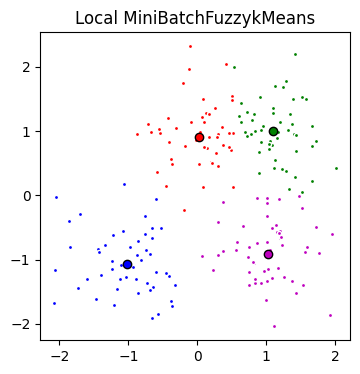

In [98]:
import matplotlib.pyplot as plt
colors = ['r', 'b', 'g', 'm']

fig = plt.figure(figsize=(4, 4))

cluster_center = fuzzy_k_means._centroids
preds = fuzzy_k_means.predict(X)
n_clusters = 4

for k, col in zip(range(n_clusters), colors):
    my_members = preds == k
    cluster_center = fuzzy_k_means._centroids[k]
    plt.plot(X[my_members, 0], X[my_members, 1], 'w',
            markerfacecolor=col, marker='.')
    plt.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col,
            markeredgecolor='k', markersize=6)
plt.title('Local MiniBatchFuzzykMeans')

In [72]:
cluster_center 

array([[-1.01758317, -1.08276943],
       [ 1.06252551,  1.04149752],
       [ 0.00636407,  0.85906258],
       [ 1.04349263, -0.90415884]])

In [10]:
from typing import List, Tuple, Dict
def generate_federated_clustering_dataset(dataset: np.ndarray,
                                          labels: np.ndarray,
                                          nodes_id: List[str],
                                          nb_samples_per_nodes: list,
                                         random_seed:int=None) -> Tuple[Dict[str, np.ndarray],
                                                                        Dict[str, np.ndarray]]:
    """
    Split classification / clustering dataset into several nodes
    
    Args:
    
    Returns:
    federated_dataset (Dict[str, np.ndarray]): a dictionary containing node id defined in argument
    `nodes_id` mapping their respective training input datasets
    federated_labels (Dict[str, np.ndarray]]): a dictionary containing node id defined in argument
    `nodes_id` mapping their respective training label datasets (from which cluster point in 
    `federated_dataset` returned argument belongs to)
    """
    
    assert len(nodes_id) == len(nb_samples_per_nodes), "len(nodes_id) must equal len(nb_samples_per_nodes)"
    nb_samples_per_nodes = np.array(nb_samples_per_nodes)
    w_sum_nodes = nb_samples_per_nodes / nb_samples_per_nodes.sum()
    
    nb_samples = labels.shape[0]
    w_sum_nodes *= nb_samples
    
    print(w_sum_nodes)
    
        
    all_X, all_labels = {}, {}
    labels_tags = np.unique(labels)
    n_labels = len(labels_tags)
        
    idx_pointer = np.zeros((n_labels))
    
    # this part is for splitting equally cluster for nodes
    # making sure every clients have the same number of labels
    for i,idx in enumerate(w_sum_nodes):
        # iterates over node"
        for i_lab, lab in enumerate(labels_tags):
            label_idx = lab == labels

            idx1 = int(idx_pointer[i_lab])
            idx2 = idx1 + int(np.floor(idx / n_labels))

            #idx1_sample, idx2_sample = int(np.floor(idx / n_labels)), int(np.floor(idx / n_labels))
            sampled_X, sampled_labels = (dataset[label_idx][idx1: idx2],
                                            labels[label_idx][idx1: idx2])
            if nodes_id[i] not in all_X.keys():
                all_X[nodes_id[i]] = sampled_X
                all_labels[nodes_id[i]] = sampled_labels
            else:
                all_X[nodes_id[i]] = np.concatenate([all_X[nodes_id[i]], sampled_X], axis=0)
                all_labels[nodes_id[i]] = np.concatenate([all_labels[nodes_id[i]], sampled_labels], axis=0)
            idx1 = idx2
            idx_pointer[i_lab] = idx1
        
    
    
    # this part is for splitting remaining points into 
    # nodes datasets (that could occur if data points in original dataset
    # divided by number of clients is not equal to an integer):
    # as a consequence, datasets among clients will be uneven
    remaining_data_pts = dataset.shape[0] - idx_pointer.sum()
    print("remaining : ", remaining_data_pts, " points")
    for i,idx in enumerate(w_sum_nodes):

        if all_labels[nodes_id[i]].shape[0] < idx:
            diff = np.abs(all_labels[nodes_id[i]].shape[0] - idx)
            diff = np.ceil(diff)
            #diff = nb_samples - idx_pointer.sum()
            
            while diff> 0 and remaining_data_pts >0:
                for i_lab, lab in enumerate(labels_tags):

                    label_idx = lab == labels
                    idx1 = int(idx_pointer[i_lab])
                    #maximum = int(np.ceil(labels[label_idx].shape[0] / len(nodes_id)))
                    maximum = int(labels[label_idx].shape[0])

                    if idx1  < maximum :


                        all_X[nodes_id[i]] = np.concatenate([all_X[nodes_id[i]],
                                                             dataset[label_idx][idx1].reshape(1,-1)],
                                                            axis=0)

                        all_labels[nodes_id[i]] = np.concatenate([all_labels[nodes_id[i]],
                                                                  np.array([labels[label_idx][idx1]])], axis=0)
                        diff -= 1
                        idx1 += 1
                        remaining_data_pts -= 1
                        idx_pointer[i_lab] = idx1
                        if diff == 0:
                            break
                    else:
                        continue
                print("added remaining point(s) to node ", nodes_id[i])
                
        print(idx_pointer)
        
        # randomly permute index of dataset of each node
        if random_seed is not None:
            rng = np.random.RandomState(random_seed)
            permuted_idx = rng.permutation(all_labels[nodes_id[i]].shape[0])
            all_X[nodes_id[i]]  = all_X[nodes_id[i]] [permuted_idx]
            all_labels[nodes_id[i]] = all_labels[nodes_id[i]][permuted_idx]
    return all_X, all_labels

In [11]:
nodes_id = ["alice", "bob", "charlie", "danny"]
n_rounds = 200
distance_metric = "euclidean"
nb_samples_per_nodes = [1, 1, 1, 1] # indicates how to sample data per node -> here nodes are sampled uniformly

federated_dataset, federated_labels = generate_federated_clustering_dataset(X,
                                                                            labels_true,
                                                                            nodes_id,
                                                                            nb_samples_per_nodes,
                                                                            random_seed=SEED
                                                                           )

[50. 50. 50. 50.]
remaining :  8.0  points
added remaining point(s) to node  alice
[49. 49. 48. 48.]
added remaining point(s) to node  bob
[50. 50. 48. 48.]
added remaining point(s) to node  charlie
[50. 50. 49. 49.]
added remaining point(s) to node  danny
[50. 50. 50. 50.]


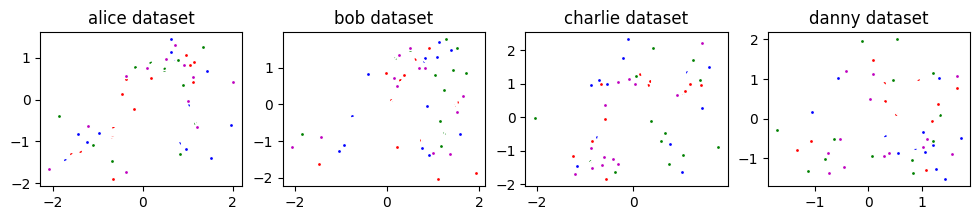

In [12]:
plt.figure(figsize=(12, 2))
n_clients = len(nodes_id)
for n_cli, cli in enumerate(nodes_id):
    plt.subplot(1, n_clients, n_cli+1)
    for k, col in zip(range(n_clusters), colors):
        my_members = federated_labels[cli] == k
        
        plt.plot(federated_dataset[cli][my_members, 0], federated_dataset[cli][my_members, 1], 'w',
                markerfacecolor=col, marker='.')
        
        plt.title(f"{cli} dataset")

In [49]:
nodes = {}

for n in nodes_id:
    fmbk = FuzzyKmeans(4, 2)
    nodes[n] = {'model' : fmbk, 'loss': []}

In [33]:
X

array([[ 1.52881659, -1.3957444 ],
       [ 0.63970563,  1.44358147],
       [ 0.46550561,  0.74405935],
       [ 0.09673212,  0.75162753],
       [-0.68018362, -1.48101442],
       [ 1.01807097, -0.0374888 ],
       [ 2.01530181,  0.42868436],
       [ 1.1238961 ,  0.55142161],
       [-1.23701045, -1.02834786],
       [-0.659672  , -1.9092495 ],
       [ 0.51288183,  0.96482756],
       [ 0.95438983,  1.07796163],
       [-0.36380246, -1.7247833 ],
       [ 0.72587878,  0.92769025],
       [ 1.2201332 , -0.65551407],
       [ 0.19694613,  0.52498723],
       [ 0.8402193 , -1.30999654],
       [-1.10196643, -1.09108771],
       [ 1.42979421,  0.68173825],
       [ 1.15650656, -0.56673964],
       [-0.65294836, -0.66068516],
       [ 0.17037634,  0.90096252],
       [ 0.48607472,  0.70764089],
       [ 0.97473016, -1.18200498],
       [ 0.8961696 ,  0.34364365],
       [-1.59776187, -1.29593149],
       [ 1.95537971, -0.60601766],
       [ 0.9251989 ,  0.83332479],
       [-1.86767444,

In [43]:
fmbk.partial_fit(X)
fmbk.score

w [14.14034548 13.28874889 16.28718092 15.98839788]


<bound method FuzzyKmeans.score of <__main__.FuzzyKmeans object at 0x7f6ccb970350>>

In [134]:
from sklearn.metrics.pairwise import pairwise_distances_argmin, pairwise_distances
from scipy.optimize import linear_sum_assignment

n_rounds = 40

# federated learning
for r in range(n_rounds):
    for n in nodes_id:
        n_batch = int(np.ceil(federated_dataset[n].shape[0] / batch_size))  # compute number of batch+1 to use over one epoch
        for epoch in range(n_epochs):
            np.random.shuffle(federated_dataset[n])
            for i_batch in range(n_batch):

                if i_batch == n_batch - 1:
                    # last batch size
                    nodes[n]['model'].partial_fit(federated_dataset[n][i_batch*batch_size:]) 
                    score= nodes[n]['model'].score(federated_dataset[n][i_batch*batch_size:])
                    nodes[n]['loss'].append(score)
                else:
                    nodes[n]['model'].partial_fit(federated_dataset[n][i_batch*batch_size:(i_batch+1)*batch_size]) 
                    score = nodes[n]['model'].score(federated_dataset[n][i_batch*batch_size:(i_batch+1)*batch_size])
                    nodes[n]['loss'].append(score)

    # TODO: perform reconsilation: as kmeans, use pairwise distance


    # federated agg
    # recognize order
    new_centroids = np.zeros_like(nodes[nodes_id[0]]['model']._centroids)
    weights = [nodes[n]['model']._weights for n in nodes_id]
    total_weights = np.sum(weights, axis=0)
    
    ref_centroids = nodes[nodes_id[0]]["model"]._centroids
    for i, n in enumerate(nodes_id):
        comp_centroids = nodes[n]["model"]._centroids
        # Cost matrix between reference and current client's centroids
        cost = pairwise_distances(ref_centroids, comp_centroids)
        # Optimal one-to-one assignment
        row_ind, col_ind = linear_sum_assignment(cost)
        if len(nodes_id) > 1:
                for ref_idx, comp_idx in zip(row_ind, col_ind):
                        new_centroids[ref_idx] += (
                            nodes[n]["model"]._weights[comp_idx]
                            * comp_centroids[comp_idx]
                        )

   
    # Aggregate centroids
        #for j in range(4): # nb clusters

         #   new_centroids[j] += nodes[n]['model']._weights[order][j] * nodes[n]['model']._centroids[order][j]
    for j in range(new_centroids.shape[0]): # nb_clusters
        new_centroids[j] /= total_weights[j]
    
    
    for n in nodes_id:
        nodes[n]['model']._centroids = new_centroids
    print('round', r, 'xb score', sum(nodes[n]['loss'][-1] for n in nodes_id))
    

w [5.0420112  1.87494022 2.91642577 2.90042087]
w [3.96613882 2.39644057 2.04100784 3.40967687]
w [1.63988259 0.83034222 0.77955749 2.52019454]
w [4.36786738 3.0881274  3.44626797 3.20533313]
w [4.11391785 2.2709644  1.83693025 4.72053408]
w [2.75696787 0.87727341 0.54310104 2.55665199]
w [5.89782263 2.90150356 2.29319228 2.78069183]
w [4.39327978 1.24673687 1.63240393 5.51047209]
w [1.36970003 1.98155355 0.59825295 2.05941251]
w [2.44518659 1.30958221 4.81050182 3.13539494]
w [1.94583403 5.6228869  2.44148992 1.21034231]
w [2.31762921 1.84103193 1.78229085 0.59354563]
w [2.35876277 4.90900113 2.9220528  1.80048124]
w [2.90979145 3.56614921 3.26301482 1.73445499]
w [1.38159003 1.13879923 3.05086689 1.71357016]
w [3.323352   3.49469182 2.9751291  1.9189507 ]
w [1.55417228 4.04240643 5.4544596  2.00498258]
w [1.46487129 1.9825216  1.16063602 1.24779554]
w [2.64397566 3.02082378 1.32527907 4.76716822]
w [2.7310792  4.06505267 2.46225861 3.24333057]
w [2.76872196 1.6391005  1.36313534 0.77

In [132]:
cluster

3

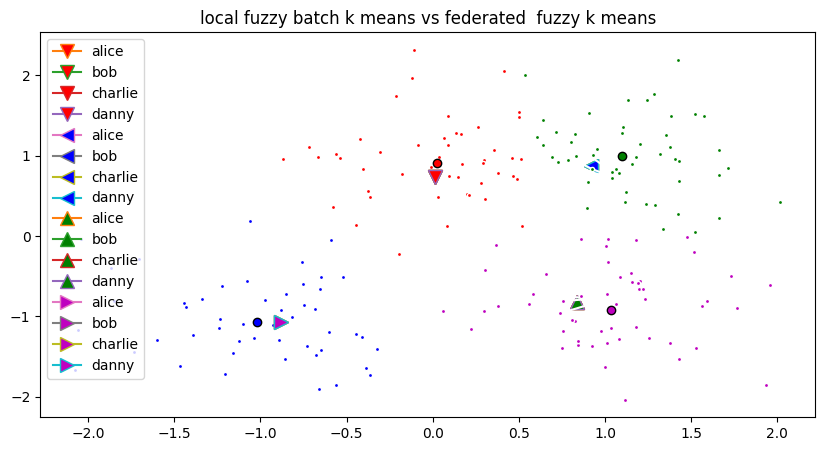

In [135]:
plt.figure(figsize=(10,5))
markers = ["v", "<", "^", ">"]
# display locally trained fuzzy k means
for k, col in zip(range(n_clusters), colors):
    my_members = preds == k
    cluster_center = fuzzy_k_means._centroids[k]
    plt.plot(X[my_members, 0], X[my_members, 1], 'w',
            markerfacecolor=col, marker='.')
    plt.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col,
            markeredgecolor='k', markersize=6)
    
    for i, n in enumerate(nodes.keys()):
        plt.plot(nodes[n]['model']._centroids[k,0],
                nodes[n]['model']._centroids[k,1],
                 marker=markers[k],  label=str(n), ms=10, mew=1, markerfacecolor=col)
    
    plt.title("local fuzzy batch k means vs federated  fuzzy k means")
plt.legend()

In [128]:
nodes[n]['model']._centroids

array([[ 0.85251361,  1.85042582],
       [ 1.22529577,  2.04991763],
       [-2.07517341, -2.23975284],
       [ 2.21335777, -1.95081212]])

In [119]:
nodes['danny']['model']._centroids

array([[ 1.09424573,  0.77950692],
       [ 0.10465751,  0.89780363],
       [-0.94376477, -1.06623147],
       [ 1.11577731, -0.94931545]])

In [68]:
weights = [nodes[n]['model']._weights for n in nodes_id]

# Aggregate centroids
new_centroids = np.zeros_like(nodes[nodes_id[0]]['model']._centroids)
total_weights = np.sum(weights, axis=0)

In [69]:
weights

[array([1.88179207, 1.3406621 , 0.8657123 , 1.05140529]),
 array([1.02352931, 2.33256672, 0.49576723, 1.3903948 ]),
 array([0.84564081, 2.33887644, 1.49812346, 2.65148329]),
 array([2.9497611 , 2.06001471, 0.40447782, 0.53304404])]

In [49]:
total_weights

array([11.79904442,  8.24005886,  1.61791128,  2.13217614])

In [62]:


for i, n in enumerate(nodes_id):
    ref_order_model = nodes[nodes_id
                            [0]]['model']
    if len(nodes_id) > 1:
        comp_model = nodes[n]['model']
        order = pairwise_distances_argmin(ref_order_model._centroids,
                                          comp_model._centroids,
                                             metric="euclidean")

In [67]:
local_centroids

[array([[2.52725858, 2.52725858],
        [1.99187304, 1.99187304]]),
 array([[9.00812696, 9.00812696],
        [8.47274142, 8.47274142]])]

In [71]:




for j in range(4): # nb clusters
    for k, n in enumerate(nodes_id):
        new_centroids[j] += nodes[n]['model']._weights[j] * nodes[n]['model']._centroids[j]
    new_centroids[j] /= total_weights[j]

centroids = new_centroids

In [72]:
centroids

array([[ 0.64152237,  0.88101935],
       [ 0.56252221, -0.93120894],
       [ 0.23089702,  0.51122954],
       [-0.11306204, -0.69339769]])

In [73]:
order

array([2, 1, 3, 0])